In [1]:
import os, re, random, string
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

class Config:
    #模型
    model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
    max_length = 256
    batch_size = 128                    
    gradient_accumulation_steps = 1    
    epochs = 20
    learning_rate = 3e-5
    warmup_ratio = 0.1
    weight_decay = 0.05
    dropout = 0.3
    # 在线文本攻击
    online_attack_prob = 0.5

    # FGM 对抗训练
    use_fgm = True
    fgm_epsilon = 0.3

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_labels = 4
    data_path = '/workspace/data/merged_dataset.csv'
    predict_path = "/workspace/data/test_dataset.csv"
    output_path = "/workspace/data/predictions.csv"
    model_save_dir = "/workspace/llama_classifier"

cfg = Config()
print(f"Using device: {cfg.device}")
print(f"Model: {cfg.model_name}")

Using device: cuda
Model: TinyLlama/TinyLlama-1.1B-Chat-v1.0


In [3]:
def load_and_split_data(csv_path):
    df = pd.read_csv(csv_path)
    df['text'] = df['text'].fillna('').astype(str)
    df['label'] = df['label'].astype(int)
    df = df[df['text'].str.strip() != '']
    df = df[df['text'].str.len() >= 5]

    texts = df['text'].tolist()
    labels = df['label'].values
    train_texts, temp_texts, train_labels, temp_labels = train_test_split(
        texts, labels, test_size=0.4, stratify=labels, random_state=42
    )
    val_texts, test_texts, val_labels, test_labels = train_test_split(
        temp_texts, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
    )
    print(f"Original Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")
    return (train_texts, train_labels), (val_texts, val_labels), (test_texts, test_labels)

In [ ]:
# 随机字符删除
def random_char_deletion(text, p=0.05):
    if len(text) < 10:
        return text
    chars = list(text)
    i = 0
    while i < len(chars):
        if random.random() < p and chars[i] != ' ':
            del chars[i]
        else:
            i += 1
    return ''.join(chars)
# 随机交换
def random_word_swap(text, p=0.1):
    words = text.split()
    if len(words) < 3:
        return text
    new_words = words.copy()
    for i in range(len(new_words)-1):
        if random.random() < p:
            new_words[i], new_words[i+1] = new_words[i+1], new_words[i]
    return ' '.join(new_words)
# 同义词替换
def get_wordnet_synonyms(word):
    synonyms = set()
    for syn in wn.synsets(word):
        for lemma in syn.lemmas():
            syn_word = lemma.name().replace('_', ' ').lower()
            if syn_word != word.lower():
                synonyms.add(syn_word)
    return list(synonyms)

def random_synonym_replacement(text, p=0.1):
    words = text.split()
    new_words = []
    for w in words:
        if random.random() < p and w.isalpha():
            syns = get_wordnet_synonyms(w)
            if syns:
                new_words.append(random.choice(syns))
            else:
                new_words.append(w)
        else:
            new_words.append(w)
    return ' '.join(new_words)
# 字符插入
def random_character_insertion(text, p=0.05):
    words = text.split()
    new_words = []
    for w in words:
        if random.random() < p and len(w) > 2:
            pos = random.randint(0, len(w)-1)
            rand_char = random.choice(string.ascii_lowercase)
            w = w[:pos] + rand_char + w[pos:]
        new_words.append(w)
    return ' '.join(new_words)
# 键盘临近替换
def keyboard_typo(text, p=0.05):
    keyboard_map = {
        'a': 'sq', 'b': 'vgh', 'c': 'xdfv', 'd': 'sfc', 'e': 'wdr',
        'f': 'dgc', 'g': 'fvh', 'h': 'gjb', 'i': 'uoj', 'j': 'hkm',
        'k': 'jlm', 'l': 'k', 'm': 'nj', 'n': 'bhm', 'o': 'ipl',
        'p': 'o', 'q': 'wa', 'r': 'etd', 's': 'awd', 't': 'ryg',
        'u': 'yih', 'v': 'cgb', 'w': 'qes', 'x': 'zsc', 'y': 'tuh',
        'z': 'xs'
    }
    words = text.split()
    new_words = []
    for w in words:
        if random.random() < p and len(w) > 1:
            chars = list(w)
            idx = random.randint(0, len(chars)-1)
            c = chars[idx].lower()
            if c in keyboard_map:
                replacement = random.choice(keyboard_map[c])
                chars[idx] = replacement if c.islower() else replacement.upper()
            w = ''.join(chars)
        new_words.append(w)
    return ' '.join(new_words)
# 大小写替换
def random_case_change(text, p=0.1):
    words = text.split()
    new_words = []
    for w in words:
        if random.random() < p:
            w = w.upper() if random.random() > 0.5 else w.lower()
        new_words.append(w)
    return ' '.join(new_words)

# 美式/英式拼写
BRITISH_SPELLING = {
    'color': 'colour', 'favorite': 'favourite', 'honor': 'honour', 'neighbor': 'neighbour',
    'center': 'centre', 'theater': 'theatre', 'meter': 'metre', 'realize': 'realise',
    'organize': 'organise', 'apologize': 'apologise', 'recognize': 'recognise'
}
def alternative_spelling(text, p=0.1):
    words = text.split()
    new_words = []
    for w in words:
        if random.random() < p and w.lower() in BRITISH_SPELLING:
            new_w = BRITISH_SPELLING[w.lower()]
            if w[0].isupper():
                new_w = new_w.capitalize()
            new_words.append(new_w)
        else:
            new_words.append(w)
    return ' '.join(new_words)

# 冠词删除
ARTICLES = {'a', 'an', 'the'}
def article_deletion(text, p=0.3):
    words = text.split()
    new_words = [w for w in words if not (w.lower() in ARTICLES and random.random() < p)]
    return ' '.join(new_words)

# 添加段落换行
def add_paragraph(text, p=0.2):
    sentences = re.split(r'(?<=[.!?])\s+', text)
    new_sentences = []
    for sent in sentences:
        new_sentences.append(sent)
        if random.random() < p:
            new_sentences.append('\n\n')
    return ''.join(new_sentences)

# 大小写交换
def upper_lower_swap(text, p=0.05):
    chars = list(text)
    for i in range(len(chars)):
        if chars[i].isalpha() and random.random() < p:
            chars[i] = chars[i].swapcase()
    return ''.join(chars)

# 插入零宽空格
def zero_width_space(text, p=0.3):
    chars = list(text)
    i = 0
    while i < len(chars):
        if chars[i] != ' ' and random.random() < p:
            chars.insert(i, '\u200b')
            i += 1
        i += 1
    return ''.join(chars)

# 插入额外空格
def whitespace_insertion(text, p=0.05):
    chars = list(text)
    i = 0
    while i < len(chars):
        if chars[i] != ' ' and random.random() < p:
            chars.insert(i, ' ')
            i += 1
        i += 1
    return ''.join(chars)

# 同形替换
HOMOGLYPHS = {
    'a': 'а', 'c': 'с', 'e': 'е', 'o': 'о', 'p': 'р', 's': 'ѕ',
    'x': 'х', 'y': 'у', 'i': 'і', 'l': 'ⅼ', 'b': 'Ь', 'h': 'һ',
    'k': 'κ', 'm': 'ⅿ', 'n': 'п', 't': 'т', 'w': 'ѡ', 'z': 'ᴢ'
}
def homoglyph_replacement(text, p=0.05):
    chars = list(text)
    for i in range(len(chars)):
        if chars[i].lower() in HOMOGLYPHS and random.random() < p:
            orig = chars[i].lower()
            glyph = HOMOGLYPHS[orig]
            chars[i] = glyph.upper() if chars[i].isupper() else glyph
    return ''.join(chars)

# 打乱数字
def shuffle_numbers(text, p=0.3):
    def shuffle_match(match):
        num = match.group()
        if random.random() < p:
            lst = list(num)
            random.shuffle(lst)
            return ''.join(lst)
        return num
    return re.sub(r'\b\d+\b', shuffle_match, text)

# 常见拼写错误
COMMON_MISSPELLINGS = {
    'the': 'teh', 'and': 'an d', 'of': 'fo', 'to': 'ot', 'you': 'uoy',
    'that': 'taht', 'with': 'wiht', 'this': 'htis', 'have': 'hvae',
    'from': 'frome', 'they': 'tehy', 'your': 'yrou', 'know': 'konw'
}
def misspelling(text, p=0.1):
    words = text.split()
    new_words = []
    for w in words:
        if random.random() < p and w.lower() in COMMON_MISSPELLINGS:
            new_w = COMMON_MISSPELLINGS[w.lower()]
            if w[0].isupper():
                new_w = new_w.capitalize()
            new_words.append(new_w)
        else:
            new_words.append(w)
    return ' '.join(new_words)

# 所有轻量级攻击列表
LIGHT_ATTACKS = [
    random_char_deletion, random_word_swap, random_synonym_replacement,
    random_character_insertion, keyboard_typo, random_case_change,
    alternative_spelling, article_deletion, add_paragraph, upper_lower_swap,
    zero_width_space, whitespace_insertion, homoglyph_replacement,
    shuffle_numbers, misspelling
]

def apply_online_attack(text, attack_prob=0.5):
    # 以一定概率随机选择一种攻击应用于文本
    if random.random() < attack_prob:
        attack_func = random.choice(LIGHT_ATTACKS)
        try:
            return attack_func(text)
        except Exception:
            return text
    else:
        return text

In [5]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length, is_train=False, attack_prob=0.5):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.is_train = is_train
        self.attack_prob = attack_prob

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        if self.is_train:
            text = apply_online_attack(text, self.attack_prob)

        enc = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [ ]:
class FGM:
    def __init__(self, model, epsilon=0.3):
        self.model = model
        self.epsilon = epsilon
        self.backup = {}

    def attack(self):
        
        for name, param in self.model.named_parameters():
            if param.requires_grad and ('embed_tokens' in name or 'embed' in name):
                if param.grad is None:
                    continue
                grad = param.grad
                if torch.isnan(grad).any() or torch.isinf(grad).any():
                    continue
                norm = torch.norm(grad)
                if norm > 1e-6 and not torch.isnan(norm) and not torch.isinf(norm):
                    self.backup[name] = param.data.clone()
                    r_at = self.epsilon * grad / norm
                    param.data.add_(r_at)

    def restore(self):
        for name, param in self.model.named_parameters():
            if name in self.backup:
                param.data = self.backup[name]
        self.backup.clear()


In [ ]:
# 加载tokenizer
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
# 加载模型
model = AutoModelForSequenceClassification.from_pretrained(
    cfg.model_name,
    num_labels=cfg.num_labels,
    ignore_mismatched_sizes=True,
    dtype=torch.bfloat16
)
model = model.to(cfg.device)
model.config.pad_token_id = tokenizer.pad_token_id
model.config.use_cache = False  # 禁用缓存以支持梯度检查点
model.config.hidden_dropout_prob = cfg.dropout
model.config.attention_probs_dropout_prob = cfg.dropout

#全量微调
for param in model.parameters():
    param.requires_grad = True
model.requires_grad_(True)

#可训练参数
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 1,034,520,576 / 1,034,520,576 (100.0%)


In [ ]:
#数据分割与数据加载
(train_texts, train_labels), (val_texts, val_labels), (test_texts, test_labels) = load_and_split_data(cfg.data_path)

train_dataset = TextDataset(train_texts, train_labels, tokenizer, cfg.max_length, is_train=True, attack_prob=cfg.online_attack_prob)
val_dataset = TextDataset(val_texts, val_labels, tokenizer, cfg.max_length, is_train=False)
test_dataset = TextDataset(test_texts, test_labels, tokenizer, cfg.max_length, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=4, pin_memory=True)

Original Train: 8998, Val: 3000, Test: 3000


In [ ]:
num_training_steps = len(train_loader) * cfg.epochs // cfg.gradient_accumulation_steps
num_warmup_steps = int(num_training_steps * cfg.warmup_ratio)
#AdamW优化
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

In [ ]:
#评估函数
def evaluate(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(cfg.device)
            attn_mask = batch['attention_mask'].to(cfg.device)
            labels = batch['labels'].to(cfg.device)
            outputs = model(input_ids, attention_mask=attn_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return acc, f1

In [ ]:
#训练函数
def train():
    os.makedirs(cfg.model_save_dir, exist_ok=True)
    best_val_acc = 0.0
    early_stop_counter = 0
    fgm = FGM(model, epsilon=cfg.fgm_epsilon) if cfg.use_fgm else None

    train_losses = []
    val_accs = []
    global_step = 0

    for epoch in range(cfg.epochs):
        model.train()
        total_loss = 0
        total_adv_loss = 0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.epochs}")
        for step, batch in enumerate(progress_bar):
            input_ids = batch['input_ids'].to(cfg.device)
            attn_mask = batch['attention_mask'].to(cfg.device)
            labels = batch['labels'].to(cfg.device)

            # 原始损失
            outputs = model(input_ids, attention_mask=attn_mask, labels=labels)
            loss = outputs.loss
            loss = loss / cfg.gradient_accumulation_steps
            loss.backward()
            total_loss += loss.item() * cfg.gradient_accumulation_steps

            # FGM 对抗训练
            if cfg.use_fgm:
                fgm.attack()
                outputs_adv = model(input_ids, attention_mask=attn_mask, labels=labels)
                loss_adv = outputs_adv.loss
                loss_adv = loss_adv / cfg.gradient_accumulation_steps
                loss_adv.backward()
                total_adv_loss += loss_adv.item() * cfg.gradient_accumulation_steps
                fgm.restore()

            # 梯度累积与更新
            if (step + 1) % cfg.gradient_accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
                global_step += 1

            # 更新进度条显示
            postfix = {'loss': f'{loss.item():.4f}'}
            if cfg.use_fgm:
                postfix['adv_loss'] = f'{loss_adv.item():.4f}'
            progress_bar.set_postfix(postfix)

        # Epoch 结束，计算平均损失并验证
        avg_loss = total_loss / len(train_loader)
        if cfg.use_fgm:
            avg_adv_loss = total_adv_loss / len(train_loader)
            print(f"Epoch {epoch+1} | Train Loss: {avg_loss:.4f} | Adv Loss: {avg_adv_loss:.4f}")
        else:
            print(f"Epoch {epoch+1} | Train Loss: {avg_loss:.4f}")

        val_acc, val_f1 = evaluate(model, val_loader)
        train_losses.append(avg_loss)
        val_accs.append(val_acc)
        print(f"Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

        # 保存最佳模型 & 早停
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), os.path.join(cfg.model_save_dir, "best_model.bin"))
            print(f"  -> Best model saved (Acc={val_acc:.4f})")
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= 3:
                print("Early stopping triggered.")
                break

    plot_curves(train_losses, val_accs)

    # 加载最佳模型并保存
    model.load_state_dict(torch.load(os.path.join(cfg.model_save_dir, "best_model.bin")))
    model.save_pretrained(cfg.model_save_dir)
    tokenizer.save_pretrained(cfg.model_save_dir)
    return model

In [ ]:
# 预测
class PredictDataset(Dataset):
    def __init__(self, texts, ids, tokenizer, max_length):
        self.texts = texts
        self.ids = ids
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        enc = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'id': self.ids[idx]   # 确保返回 id
        }
def predict_collate_fn(batch):
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    ids = [item['id'] for item in batch]
    return {'input_ids': input_ids, 'attention_mask': attention_mask, 'id': ids}

In [ ]:
#训练损失图与验证准确率图
def plot_curves(train_losses, val_accs):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-o', label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Curve')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, val_accs, 'r-o', label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Validation Accuracy Curve')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(cfg.model_save_dir, 'training_curves.png'), dpi=150)
    plt.show()
    print(f"Training curves saved to {os.path.join(cfg.model_save_dir, 'training_curves.png')}")
#预测函数
def predict(model, tokenizer, predict_csv_path, output_csv_path):
    df_pred = pd.read_csv(predict_csv_path)
    if 'ID' not in df_pred.columns or 'text' not in df_pred.columns:
        raise ValueError("预测文件需要包含 'ID' 和 'text' 列")
    df_pred['text'] = df_pred['text'].fillna('').astype(str)
    df_pred['ID'] = df_pred['ID'].astype(int)
    df_pred = df_pred[df_pred['text'].str.strip() != '']
    ids = df_pred['ID'].tolist()
    texts = df_pred['text'].tolist()

    pred_dataset = PredictDataset(texts, ids, tokenizer, cfg.max_length)
    pred_loader = DataLoader(pred_dataset, batch_size=cfg.batch_size, shuffle=False, collate_fn=predict_collate_fn)

    model.eval()
    all_preds = []
    all_ids = []
    with torch.no_grad():
        for batch in pred_loader:
            input_ids = batch['input_ids'].to(cfg.device)
            attn_mask = batch['attention_mask'].to(cfg.device)
            outputs = model(input_ids, attention_mask=attn_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_ids.extend(batch['id'])   # 收集 id
    df_out = pd.DataFrame({'ID': all_ids, 'pred_label': all_preds})
    df_out.to_csv(output_csv_path, index=False)
    print(f"预测完成，输出 {len(df_out)} 条记录至 {output_csv_path}")
    return df_out


Epoch 1/20: 100%|██████████| 71/71 [03:05<00:00,  2.61s/it, loss=0.9766, adv_loss=1.4766]

Epoch 1 | Train Loss: 1.6616 | Adv Loss: 1.9744


Val Acc: 0.5753 | Val F1: 0.5128
  -> Best model saved (Acc=0.5753)


Epoch 2/20: 100%|██████████| 71/71 [03:04<00:00,  2.60s/it, loss=0.6719, adv_loss=0.8711]

Epoch 2 | Train Loss: 0.6701 | Adv Loss: 0.9448


...

Epoch 17 | Train Loss: 0.0037 | Adv Loss: 0.0241


Val Acc: 0.9513 | Val F1: 0.9414


Epoch 18/20: 100%|██████████| 71/71 [03:04<00:00,  2.60s/it, loss=0.0019, adv_loss=0.0374]

Epoch 18 | Train Loss: 0.0058 | Adv Loss: 0.0322


Val Acc: 0.9507 | Val F1: 0.9404
Early stopping triggered.


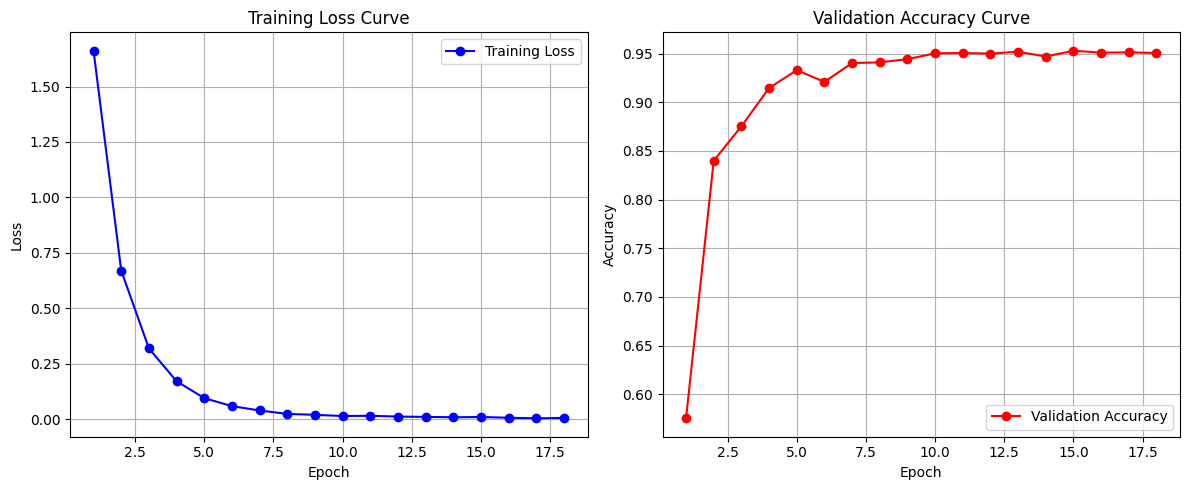

Training curves saved to ./llama_classifier/training_curves.png


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


========== 测试集评估 ==========
Test Accuracy : 0.9493
Test Macro F1  : 0.9366


In [ ]:
# 主函数，主要是训练部分和验证部分
if __name__ == "__main__":
    print("=" * 50)
    print("开始训练")
    trained_model = train()

    test_acc, test_f1 = evaluate(trained_model, test_loader)
    print("\n========== 测试集评估 ==========")
    print(f"Test Accuracy : {test_acc:.4f}")
    print(f"Test Macro F1  : {test_f1:.4f}")

    

In [ ]:
#预测部分
print("\n" + "=" * 50)
print("开始预测...")
predict(trained_model, tokenizer, cfg.predict_path, cfg.output_path)


开始预测...
预测完成，输出 1000 条记录至 /workspace/data/predictions.csv


,ID,pred_label
0,0,1
1,1,0
2,2,1
3,3,0
4,4,0
...,...,...
995,995,0
996,996,0
997,997,2
998,998,0
